## Imports

In [23]:
from utils.data_prepocessing import _ensure_monthly_index_and_align_exog, plot_forecaster_feature_importance
from utils.constants import (
CATEGORY_MAP,
BEST_PREDICTORS_FOR_INDEX
)
from utils.utils import (
    transform_and_plot_trend_for_cat,
    get_best_result_for_runs,
    plot_best_mape_predictors,
    aggregate_metrics_result,
    extrapolate_results,
    plot_known_feature_value,
    extrapolate_results_to_single_ts,
    disaggregate_category_forecast,
    plot_graphics_for_each_ts,
    get_month_beginnings
)
from utils.cluster_forecast import ClusterForecaster
from itertools import combinations
from typing import Type, Literal, Any
from darts import TimeSeries
import pandas as pd
import os
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings('ignore')

---
## Data prepocessing

In [24]:
directory = "Data/"  # set directory path
d = {}
formed = {}

for i, entry in enumerate(os.scandir(directory)):  
    if entry.is_file() and entry.name.endswith('.xlsx'):  # check if it's a file
        # print(entry.name)
        d[entry.name] = pd.read_excel(f"{directory}{entry.name}")
    elif entry.is_file() and entry.name.endswith('.csv'):
        formed[entry.name] = pd.read_csv(f"{directory}{entry.name}")

global_macros = d["global_macro.xlsx"]
apk_nona = formed["apk_nona.csv"]

chemicals_nona = formed["chemicals_nona.csv"]
chemicals_nona["Date"] = pd.to_datetime(chemicals_nona["Date"])
chemicals_nona = chemicals_nona.set_index('Date')

global_macros = global_macros.drop(columns=["Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),  .1"])

apk_nona["Date"] = apk_nona["Unnamed: 0"]
apk_nona["Date"] = pd.to_datetime(apk_nona["Date"])

global_macros = global_macros.iloc[3:][::-1].reset_index(drop=True)
global_macros = global_macros.drop(columns=["Date"])
global_macros.index = apk_nona["Date"]

apk_nona = apk_nona.set_index('Date')


assert global_macros.shape[0] == apk_nona.shape[0]


apk_nona_en, global_macros_en = _ensure_monthly_index_and_align_exog(apk_nona, global_macros)
chemicals_nona_en, global_macros_en_chemicals = _ensure_monthly_index_and_align_exog(chemicals_nona[chemicals_nona.index<=global_macros.index.max()],
                                                                                     global_macros[global_macros.index>=chemicals_nona.index.min()])
global_macros_en.columns = list(map(lambda x: " ".join(x.split()), list(global_macros_en.columns)))  # убираем табы

apk_nona_en_rol = transform_and_plot_trend_for_cat(apk_nona_en, 12, norm_method="index", plot_graphics=False)
chemicals_nona_en_rol = transform_and_plot_trend_for_cat(chemicals_nona_en, 12, norm_method="index", features_to_cat=CATEGORY_MAP, plot_graphics=False)

macro_data = global_macros_en[global_macros_en.index >= apk_nona_en_rol.dropna().index[0]]
df_combined = pd.concat([apk_nona_en_rol.dropna(), chemicals_nona_en_rol.dropna()], axis=1)

---
## Global parameters setting

In [25]:
print(f"Available columns to predict: {apk_nona_en.columns}, {chemicals_nona_en.columns}")

Available columns to predict: Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       'Сахар (средняя цена по России)', 'Свинина в живом весе',
       'Соевое масло', 'Соевый шрот', 'Соя', 'Яйцо товарное',
       'Подсолнечное масло наливом (мировые цены)',
       'Бутилированное подсолнечное масло (рафинированное)',
       'Подсолнечный шрот ', 'Колбасы сырокопченые', 'Баранина в живом весе',
       'Баранина в убойном весе ', 'Какао-бобы (USD)', 'Какао-бобы',
       'Подсолнечное масло (наливом) не бутилированное, нерафинированное ',
       'Кокосовое масло (USD) ', 'Кокосовое масло ', 'Пальмовое масло (USD)',
       'Пальмовое масло ', 'Табак (USD)', 'Табак', 'Пшеница 4-го класса',
       'Минтай б/г, Владивосток руб./кг', 'Минтай б/г, Китай C&F $/т',
       'Сельдь н/р, Владивосток руб

## Описание параметров запуска

### Основные параметры прогнозирования
- `PREDICTION_HORIZON_APK = 12` - горизонт прогнозирования (месяцев) для APK
- `PREDICTION_HORIZON_CHEMICALS = 12` - горизонт прогнозирования (месяцев) для химических продуктов
- `NAIVE_PREDICTOR_WINDOW_LENGTH_APK = 12` - длина окна для наивного прогноза APK
- `NAIVE_PREDICTOR_WINDOW_LENGTH_CHEMICALS = 12` - длина окна для наивного прогноза химических продуктов
- `PREDICTOR_LAG_APK = 12` - лаг предикторов для APK
- `PREDICTOR_LAG_CHEMICALS = 12` - лаг предикторов для химических продуктов

### Режимы работы и даты
- `IS_BACKTEST: bool = True` - режим бэктеста (True - тестирование на исторических данных, False - реальный прогноз)
- `BACKTEST_DATE_CHEMICALS` - дата начала бэктеста для химических продуктов
- `BACKTEST_DATE_APK` - дата начала бэктеста для APK
- `SINGLE_DATAPOINT_TO_PRED = "2026-04-14"` - целевая дата для прогноза

### Пути сохранения результатов
- `NAIVE_PREDICTOR_RESULT_PATH_APK` - путь для сохранения наивных прогнозов APK
- `NAIVE_PREDICTOR_RESULT_PATH_CHEMICALS` - путь для сохранения наивных прогнозов химических продуктов

### Параметры моделей
- `TARGET_COL_SUFFIX = "_sum"` - суффикс целевой переменной
- `MODEL_NAME_FOR_FORECASTER = "nbeats"` - тип модели для прогнозирования
- `USE_FUTURE_COV` - использование будущих ковариат (автоматически определяется по типу модели)

### Целевые временные ряды
- `TS_TO_PREDICT_APK = "Соя"` - целевой продукт для прогноза APK
- `TS_TO_PREDICT_CHEMICALS = "Карбамид (FOB Южный)"` - целевой продукт для прогноза химических продуктов

### Временные параметры
- `FUTURE_DATE_APK` - будущая дата для APK
- `train_end` - конец обучающего периода
- `past_idx` - даты исторических данных для обучения
- `future_idx` - даты будущего периода для прогноза

### Параметры внешних факторов
- `FUTURE_FORECASTER_TS_NAME = "Инфляция, г/г"` - название макроэкономического показателя
- `FUTURE_FORECASTER_TS_VALUES` - известные будущие значения макропоказателя

### Управление моделями
- `MODEL_SAVE_PATH` - шаблон пути для сохранения моделей
- `PERSIST_MODEL = True` - флаг сохранения моделей на диск
- `REFIT_MODEL = True` - флаг переобучения моделей

In [34]:
PREDICTION_HORIZON_APK = 12
NAIVE_PREDICTOR_WINDOW_LENGTH_APK = 12
PREDICTION_HORIZON_CHEMICALS = 12
NAIVE_PREDICTOR_WINDOW_LENGTH_CHEMICALS = 12
PREDICTOR_LAG_APK = 12
PREDICTOR_LAG_CHEMICALS = 12

IS_BACKTEST: bool = True
BACKTEST_DATE_CHEMICALS = chemicals_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_CHEMICALS*2)

SINGLE_DATAPOINT_TO_PRED = "2026-04-14"


## Directories to save naive results
NAIVE_PREDICTOR_RESULT_PATH_APK = f"darts_result_tables_naive_{PREDICTION_HORIZON_APK}"
NAIVE_PREDICTOR_RESULT_PATH_CHEMICALS = f"darts_result_tables_naive_chemicals_{NAIVE_PREDICTOR_WINDOW_LENGTH_CHEMICALS}"
## Directories to save naive results

TARGET_COL_SUFFIX = "_sum"
MODEL_NAME_FOR_FORECASTER: Literal["tftmodel", "regression", "nbeats", "naiveseasonal", "naivedrift", "naivemean", "naivemovingaverage"] = "nbeats"
USE_FUTURE_COV = MODEL_NAME_FOR_FORECASTER in ("tftmodel", "regression")
TS_TO_PREDICT_APK = "Соя"
TS_TO_PREDICT_CHEMICALS = "Карбамид (FOB Южный)"

FUTURE_DATE_APK = apk_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_APK)
BACKTEST_DATE_APK = apk_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_APK*2)

train_end = BACKTEST_DATE_APK
past_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS")
future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS")

dates = get_month_beginnings(SINGLE_DATAPOINT_TO_PRED)
date_to_pred = dates[1] if len(dates) > 1 else dates[0]
predict_end = pd.to_datetime(date_to_pred)
last_date = df_combined.reset_index()["Date"].iloc[-1]

TOTAL_RANGE = (predict_end.year - last_date.year)*12 + (predict_end.month - last_date.month)

start_date = pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - relativedelta(months=TOTAL_RANGE)
end_date = pd.to_datetime(SINGLE_DATAPOINT_TO_PRED)

# Generate the list of monthly dates
DATE_LIST = pd.date_range(start=start_date, end=end_date, freq='MS').tolist()  # MS = Month Start

DATE_LIST[-1] = pd.to_datetime(SINGLE_DATAPOINT_TO_PRED)


## Parameters with known future values
FUTURE_FORECASTER_TS_NAME = "Инфляция, г/г"
FUTURE_FORECASTER_TS_VALUES = [15.2, 14.9, 12.6, 14.4, 13.1, 13.3]*(int(TOTAL_RANGE/6))
if not FUTURE_FORECASTER_TS_VALUES:
    for _ in range(max(PREDICTION_HORIZON_APK, PREDICTION_HORIZON_CHEMICALS)):
        tmp = input()
        FUTURE_FORECASTER_TS_VALUES.append(float(tmp))

MODEL_SAVE_PATH = "{model_name}_dataset/{model_name}_for_{category_name}"

PERSIST_MODEL = True
REFIT_MODEL = False

---
## Known TS future

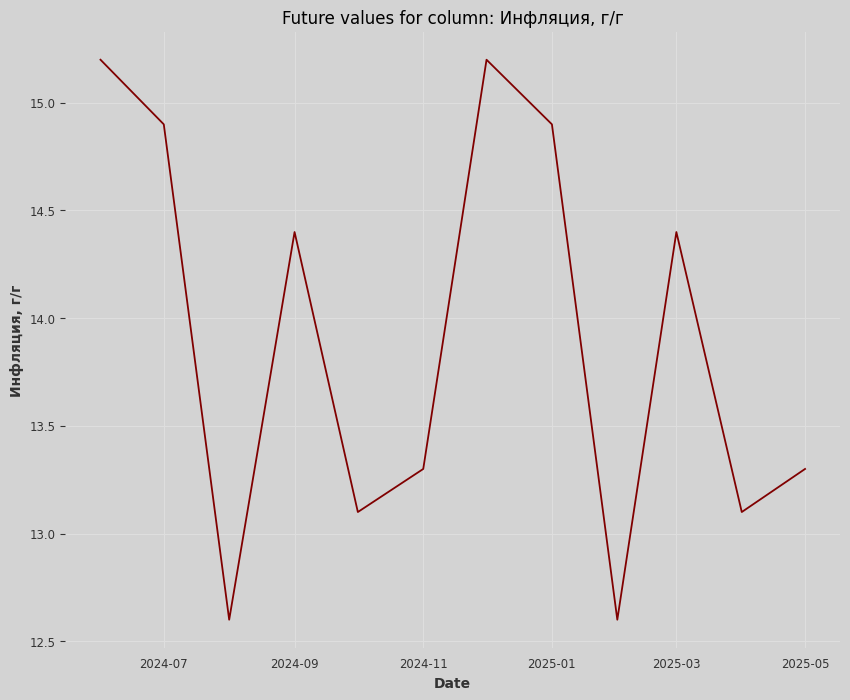

In [27]:
plot_known_feature_value(FUTURE_FORECASTER_TS_VALUES,
                         FUTURE_FORECASTER_TS_NAME,
                         pd.date_range(start=FUTURE_DATE_APK + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS"))

---
## Forecasting clusers

### utils

In [28]:
def load_models(model_name: str = MODEL_NAME_FOR_FORECASTER,
                model_save_path: str = MODEL_SAVE_PATH,
                category_map: dict[str, str] = CATEGORY_MAP):
    f_dicts = {}
    for target_cat in set(category_map.values()):
        f = ClusterForecaster.load(model_save_path.format(model_name=model_name, category_name=target_cat))
        f_dicts[target_cat] = f

    return f_dicts

In [29]:
def train_model_and_eval_res(df_in: pd.DataFrame,
                             macro_data: pd.DataFrame,
                             past_idx = past_idx,
                             future_idx = future_idx,
                             category_map: dict = CATEGORY_MAP,
                             best_predictors_for_idx: dict = BEST_PREDICTORS_FOR_INDEX,
                             target_col_suffix:str = TARGET_COL_SUFFIX,
                             future_forecaster_ts_name:str = FUTURE_FORECASTER_TS_NAME,
                             future_forecaster_ts_values: str = FUTURE_FORECASTER_TS_VALUES,
                             model_name: str = MODEL_NAME_FOR_FORECASTER,
                             use_future_macro: bool = USE_FUTURE_COV,
                             prediction_horizon: int = PREDICTION_HORIZON_APK,
                             dir_to_save_plots: str = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                             dir_to_save_tables: str = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}",
                             persist_model: bool = PERSIST_MODEL,
                             refit: bool = REFIT_MODEL
                            ):
    df = df_in.dropna()
    all_clusters = sorted(set(category_map.values()))
    forecasts_for_cluster: dict[str, Type[TimeSeries]] = {}
    forecasters_for_cluster: dict[str, Type[ClusterForecaster]] = {}
    if model_name not in ("regression"):
        past_data_for_train = df[df.index<=past_idx[-1]]
        macro_data_for_train = macro_data[macro_data.index<=past_idx[-1]]
    else:
        past_data_for_train = df[df.index<=past_idx[0]]
        macro_data_for_train = macro_data[macro_data.index<=past_idx[0]]
    trained_models: dict[str, Type[ClusterForecaster]] = {}
    for target_cat in all_clusters:
        model_save_path: str = f"{model_name}_dataset/{model_name}_for_{target_cat}"
        
        predictors_lst:list[str] = best_predictors_for_idx.get(target_cat)
    
        forecaster = ClusterForecaster(
            cluster_data=past_data_for_train,
            macro_data=macro_data_for_train,
            category_map=category_map,
            freq="M",
            target_col_suffix=target_col_suffix,
            dir_to_save_plots=dir_to_save_plots,
            dir_to_save_tables=dir_to_save_tables,
            future_macro_col=future_forecaster_ts_name,
            model_type=model_name
        )
        if os.path.isdir("".join(model_save_path.split("/")[:-1])) and not refit:
            try:
                forecaster = forecaster.load(model_save_path)
            except Exception as e:
                print(f"Did not found {model_save_path};Faild with error: {e}; Gonna train")
                forecaster.train(target_cat, predictors_lst, use_future_macro=use_future_macro)
        else:
            forecaster.train(target_cat, predictors_lst, use_future_macro=use_future_macro)

        cov_past = pd.DataFrame(index=past_idx)
        cov_past = pd.concat([cov_past, macro_data[macro_data.index < future_idx[0]]], axis=1)
        if predictors_lst:
            for additional_cluster in predictors_lst:
                all_add = df[f"{additional_cluster}{target_col_suffix}"].shift(1)
                cov_past[f"{additional_cluster}_lag1"] = all_add.reindex(past_idx)
        cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
        if IS_BACKTEST:
            cov_future = pd.concat([pd.DataFrame(macro_data[future_forecaster_ts_name][past_idx]),
               pd.DataFrame(macro_data[future_forecaster_ts_name][future_idx])])
        else:
            cov_future = pd.concat([pd.DataFrame(macro_data[future_forecaster_ts_name][past_idx]),
                                    pd.DataFrame(future_forecaster_ts_values,
                                               index=future_idx,
                                               columns=[future_forecaster_ts_name])]
                                  )        
        preds = forecaster.forecast(prediction_horizon,
                            cov_past,
                            cov_future if use_future_macro else None)
        if MODEL_NAME_FOR_FORECASTER in ("tftmodel"):
            preds *= 11
        forecasters_for_cluster[target_cat] = forecaster
        forecasts_for_cluster[target_cat] = preds
        target_s = df[df.index >= pd.to_datetime(future_idx[0])][f"{target_cat}_sum"]
        pred_ts, actual_ts, metrics = forecaster.plot_and_return_data_backtest(TimeSeries.from_series(target_s),
                                                                               preds,
                                                                               target_cat,
                                                                               future_idx,
                                                                               predictors_lst)
        # persisting
        trained_models[target_cat] = forecaster
        if persist_model:
            forecaster.save(model_save_path)
    return trained_models
            

### predictions

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.8 M  | train
---------

Epoch 99: 100%|████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.26it/s, train_loss=26.70]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.26it/s, train_loss=26.70]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 99: 100%|██████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.05it/s, train_loss=3.35e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████████████████████████████████████████████████| 3/3 [00:00<00:00,  6.94it/s, train_loss=3.35e+3]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 31.61it/s]
Saved forecaster to nbeats_dataset/nbeats_for_dip.pkl and model to nbeats_dataset/nbeats_for_dip_model.pth


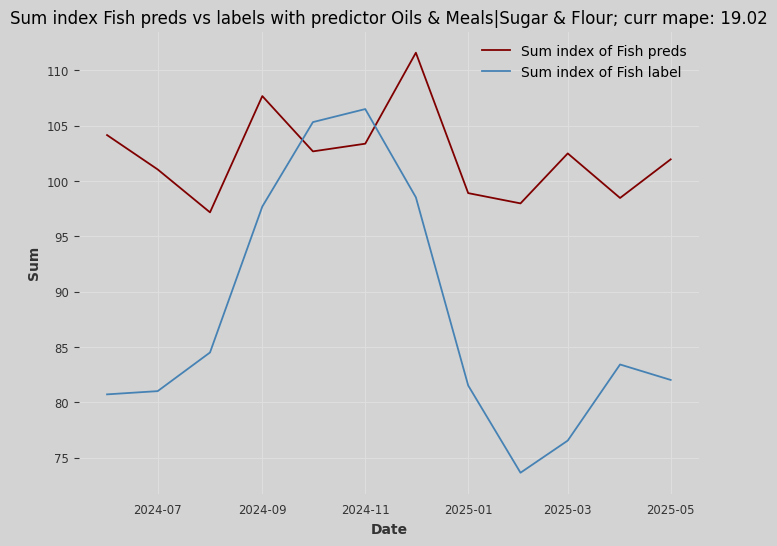

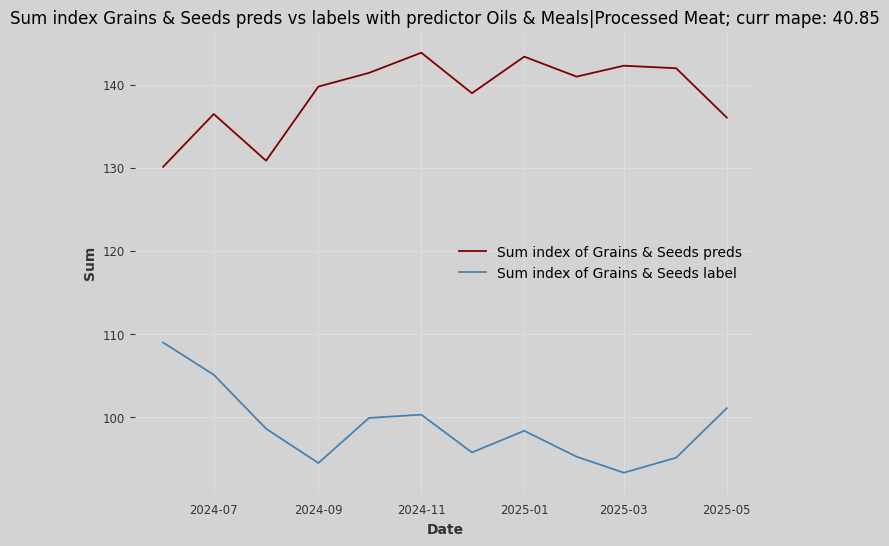

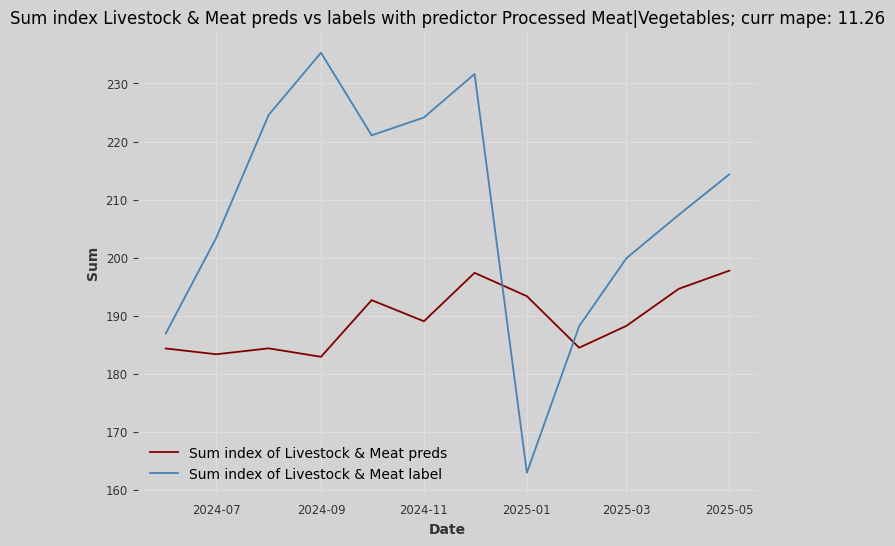

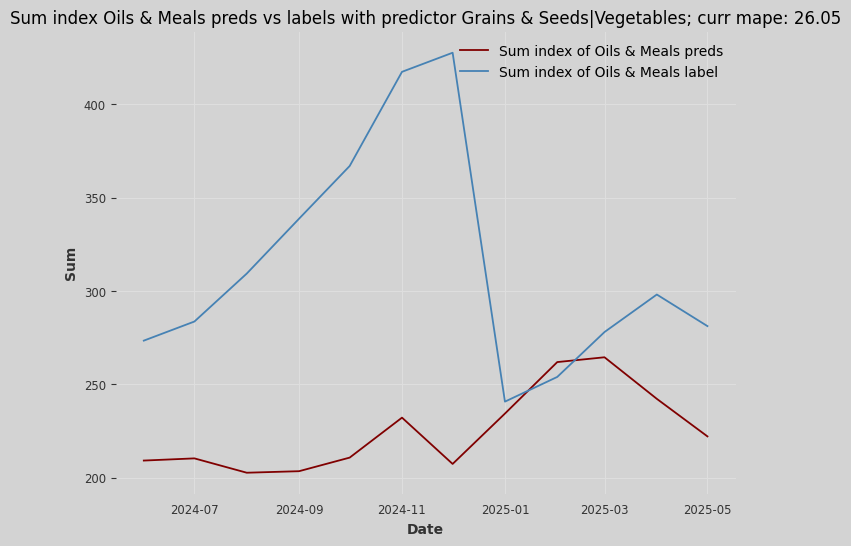

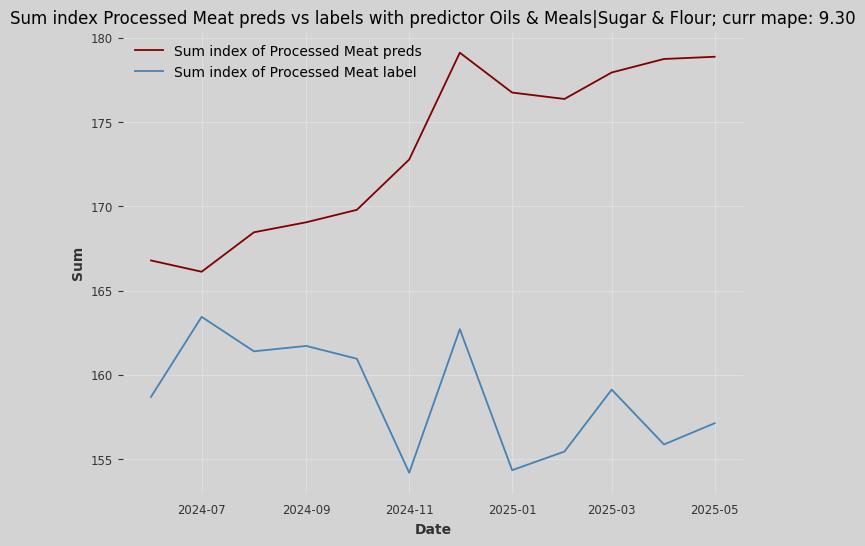

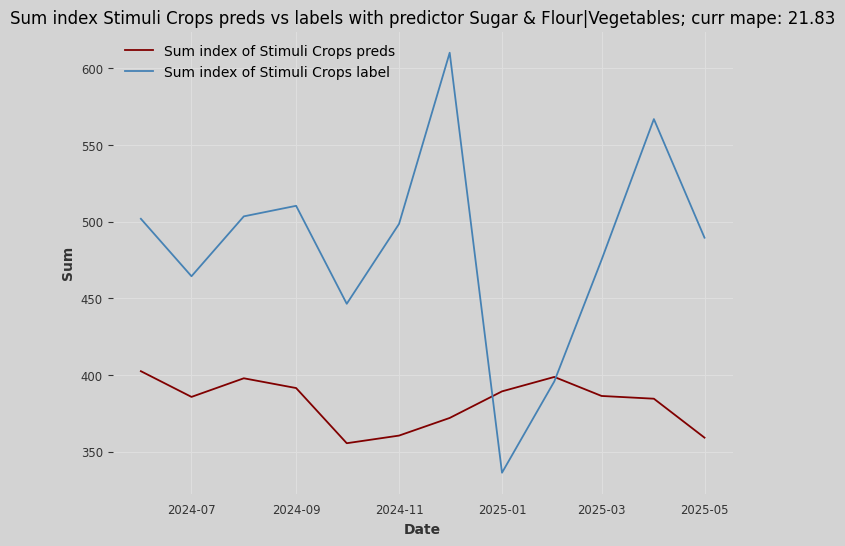

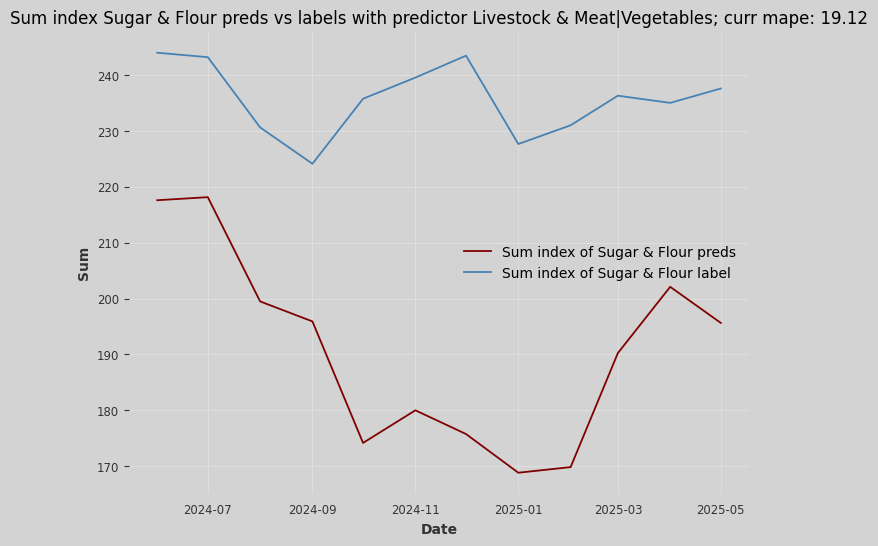

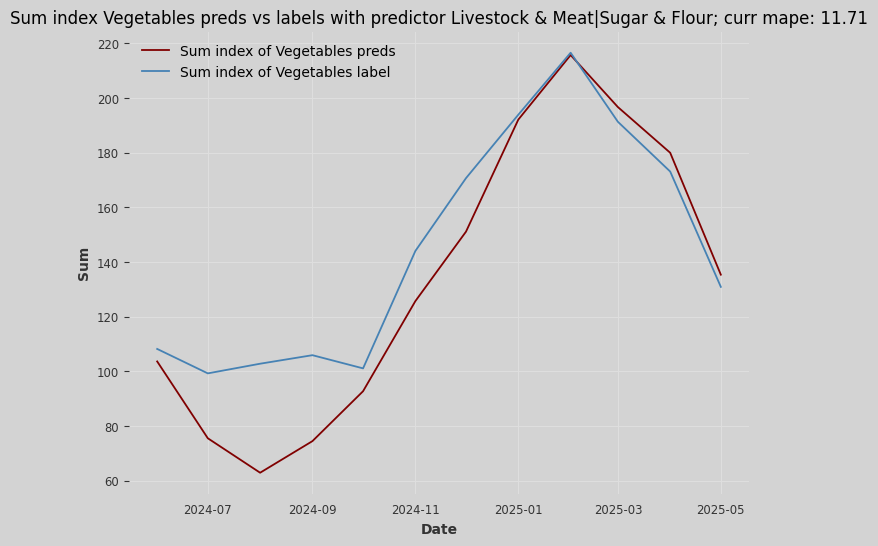

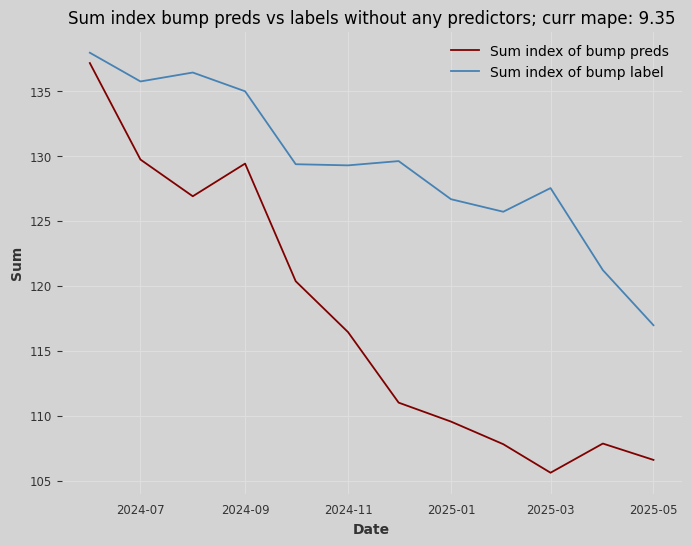

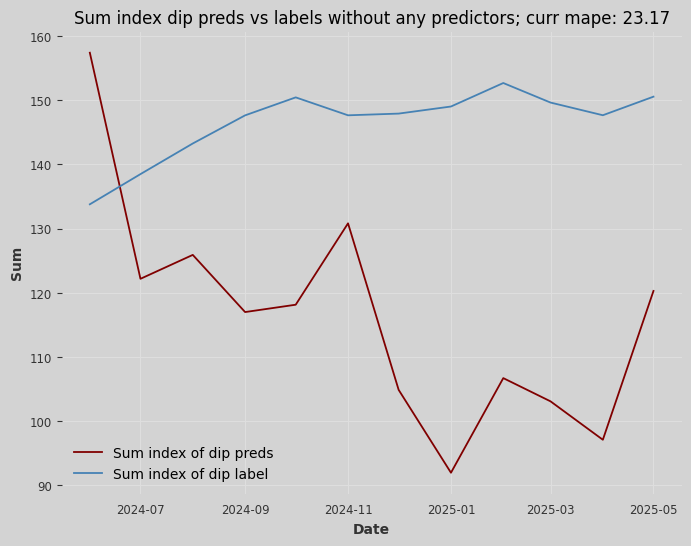

In [30]:
models = train_model_and_eval_res(df_combined,
                         macro_data,
                         past_idx = past_idx,
                         future_idx = future_idx,
                         category_map = CATEGORY_MAP,
                         best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX,
                         target_col_suffix = TARGET_COL_SUFFIX,
                         future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                         future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                         model_name = MODEL_NAME_FOR_FORECASTER,
                         use_future_macro = USE_FUTURE_COV,
                         prediction_horizon = PREDICTION_HORIZON_APK,
                         dir_to_save_plots = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         dir_to_save_tables = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}"
)

---
## Inference model

In [18]:
models = load_models()

[OK] Loaded forecaster ← regression_dataset/regression_for_bump.pkl
[OK] Loaded model      ← regression_dataset/regression_for_bump_model.pth
[OK] Loaded forecaster ← regression_dataset/regression_for_Grains & Seeds.pkl
[OK] Loaded model      ← regression_dataset/regression_for_Grains & Seeds_model.pth
[OK] Loaded forecaster ← regression_dataset/regression_for_Vegetables.pkl
[OK] Loaded model      ← regression_dataset/regression_for_Vegetables_model.pth
[OK] Loaded forecaster ← regression_dataset/regression_for_dip.pkl
[OK] Loaded model      ← regression_dataset/regression_for_dip_model.pth
[OK] Loaded forecaster ← regression_dataset/regression_for_Sugar & Flour.pkl
[OK] Loaded model      ← regression_dataset/regression_for_Sugar & Flour_model.pth
[OK] Loaded forecaster ← regression_dataset/regression_for_Stimuli Crops.pkl
[OK] Loaded model      ← regression_dataset/regression_for_Stimuli Crops_model.pth
[OK] Loaded forecaster ← regression_dataset/regression_for_Livestock & Meat.pkl
[O

In [31]:
def get_prediction_for_ts(df_in: pd.DataFrame,
                          model_category,
                          ts_to_predict_name: str = TS_TO_PREDICT_APK,
                             macro_data: pd.DataFrame = macro_data,
                             past_idx = past_idx,
                             future_idx = future_idx,
                             category_map: dict = CATEGORY_MAP,
                             best_predictors_for_idx: dict = BEST_PREDICTORS_FOR_INDEX,
                             target_col_suffix:str = TARGET_COL_SUFFIX,
                             future_forecaster_ts_name:str = FUTURE_FORECASTER_TS_NAME,
                             future_forecaster_ts_values: str = FUTURE_FORECASTER_TS_VALUES,
                             model_name: str = MODEL_NAME_FOR_FORECASTER,
                             use_future_macro: bool = USE_FUTURE_COV,
                             prediction_horizon: int = PREDICTION_HORIZON_APK,
                             weight_method_apply: str = "last"
                            ):
    df = df_in.dropna()
    category_to_pred = category_map[ts_to_predict_name]
    predictors_lst = best_predictors_for_idx[category_to_pred]
    predictors_lst = predictors_lst if predictors_lst else []
    cov_past = pd.DataFrame(index=past_idx)
    cov_past = pd.concat([cov_past, macro_data[macro_data.index < future_idx[0]]], axis=1)
    if predictors_lst:
        for additional_cluster in predictors_lst:
            all_add = df[f"{additional_cluster}{target_col_suffix}"].shift(1)
            cov_past[f"{additional_cluster}_lag1"] = all_add.reindex(past_idx)
    cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
    if IS_BACKTEST:
        cov_future = pd.concat([pd.DataFrame(macro_data[future_forecaster_ts_name][past_idx]),
           pd.DataFrame(macro_data[future_forecaster_ts_name][future_idx])])
    else:
        cov_future = pd.concat([pd.DataFrame(macro_data[future_forecaster_ts_name][past_idx]),
                                pd.DataFrame(future_forecaster_ts_values,
                                           index=future_idx,
                                           columns=[future_forecaster_ts_name])]
                              )        

    target_s = df[df.index >= pd.to_datetime(future_idx[0])][f"{category_to_pred}_sum"]
    
    predictions = model_category.forecast(TOTAL_RANGE,
                                        cov_past,
                                        cov_future if USE_FUTURE_COV else None).to_dataframe().reset_index(drop=True)
    ts_to_cats = {k: category_map[k] for k in set(list(category_map.keys())) - set(['Подсолнечное масло (наливом) не бутилированное, не'])}
    cols = [col for col, cat in ts_to_cats.items() if cat == category_to_pred and col in df.columns]
    _, _, df_per_ts, metrics_result = disaggregate_category_forecast(
                               predictions,
                               predictions,
                               category_to_pred,
                               df[cols],
                               past_idx[-1],
                                {"method": "index",
                                 "first": df[f"{category_to_pred}_sum_original"].iloc[0]
                                },
                               "_".join(predictors_lst),
                               "",
                               weight_method=weight_method_apply,
                               predict_horizon=TOTAL_RANGE,
                                plot_graph=False,
                                is_backtest=False
                              )
    metrics_general = pd.DataFrame()

    metrics_general = pd.concat([metrics_general, metrics_result], axis=1)

    df_per_ts.index = DATE_LIST
    return df_per_ts[f"{ts_to_predict_name}_preds"], metrics_general, predictions

In [32]:
category_to_pred = CATEGORY_MAP[TS_TO_PREDICT_APK]
ts_prediction, _, cluster_preds = get_prediction_for_ts(df_combined.dropna(), models[category_to_pred])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.08it/s]


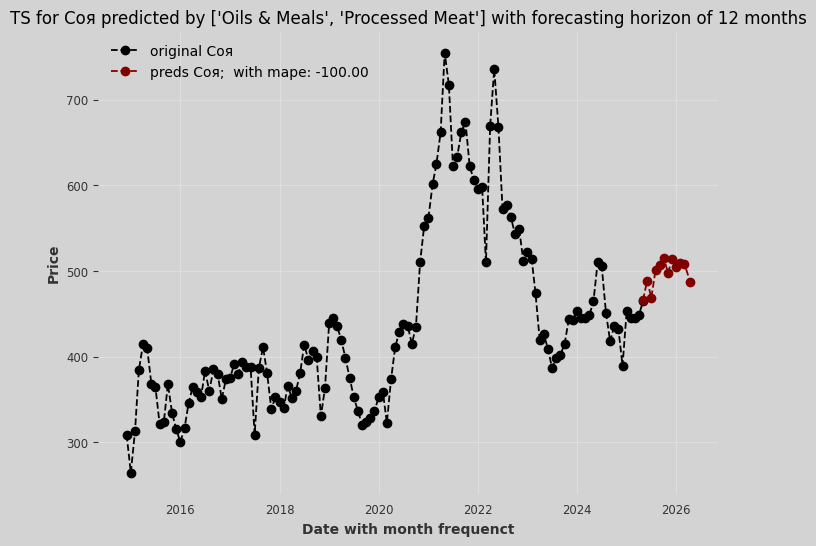

In [33]:
plot_graphics_for_each_ts(df_combined[f"{TS_TO_PREDICT_APK}"],
                          ts_prediction,
                          None,
                          TS_TO_PREDICT_APK,
                          -1,
                          -1,
                          BEST_PREDICTORS_FOR_INDEX[CATEGORY_MAP[TS_TO_PREDICT_APK]],
                          "")